# Notebook 1 — Exploração de Dados e Visualização de Drift

## Aula 1: Fundamentos do Data Drift em ML

### Objetivos
- Compreender o dataset sintético que simula o cenário da loja online
- Realizar análise exploratória (EDA) dos dados por período temporal
- Visualizar mudanças nas distribuições de features ao longo do tempo
- Identificar visualmente a presença de **data drift (covariate shift)**

### Teoria-Chave (Documento 04)

> **Data drift** (feature drift / covariate shift) ocorre quando a distribuição das variáveis de entrada muda ao longo do tempo:
> $$P_{\text{treino}}(X) \neq P_{\text{produção}}(X)$$
> enquanto $P(Y|X)$ permanece constante.
>
> — Seção *Saiba Mais — Definindo Data Drift e Concept Drift*

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona diretório raiz da aula ao path
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Geração / Carga do Dataset

O dataset simula atributos de clientes de uma **loja online** divididos em 5 períodos
temporais. A partir do período 3, injetamos **data drift** deslocando a média de
5 features demográficas — representando a mudança no perfil de clientes descrita
na seção *O Que Vem Por Aí?* do material da aula.

In [2]:
# Gera ou carrega o dataset
preprocessor = DataPreprocessor(random_state=42)

data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if data_path.exists():
    df = preprocessor.load_data(data_path)
    print(f"Dataset carregado de {data_path}")
else:
    df = preprocessor.generate_synthetic_data(n_samples=10_000)
    preprocessor.save_data(df, data_path)
    print(f"Dataset gerado e salvo em {data_path}")

print(f"\nShape: {df.shape}")
df.head()

Dataset carregado de c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\01_fundamentos_do_data_drift_em_ml\data\raw\dataset.csv

Shape: (10000, 12)


,idade,renda_mensal,tempo_no_site_min,paginas_visitadas,itens_carrinho,ticket_medio,frequencia_visitas_mes,dias_desde_ultima_compra,score_engajamento,num_categorias_visitadas,target,periodo
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,1,1
1,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,1,1
2,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,1,1
3,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,0,1
4,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0,1


## 2. Visão Geral do Dataset

Verificamos tipos de dados, estatísticas descritivas e distribuição por período.

In [3]:
# Informações gerais
print("=" * 50)
print("Tipos de dados:")
print(df.dtypes)
print("\n" + "=" * 50)
print("Valores ausentes:")
print(df.isnull().sum())
print("\n" + "=" * 50)
print("Distribuição por período:")
print(df["periodo"].value_counts().sort_index())
print("\n" + "=" * 50)
print("Distribuição do target:")
print(df["target"].value_counts())

Tipos de dados:
idade                       float64
renda_mensal                float64
tempo_no_site_min           float64
paginas_visitadas           float64
itens_carrinho              float64
ticket_medio                float64
frequencia_visitas_mes      float64
dias_desde_ultima_compra    float64
score_engajamento           float64
num_categorias_visitadas    float64
target                        int64
periodo                       int64
dtype: object

Valores ausentes:
idade                       0
renda_mensal                0
tempo_no_site_min           0
paginas_visitadas           0
itens_carrinho              0
ticket_medio                0
frequencia_visitas_mes      0
dias_desde_ultima_compra    0
score_engajamento           0
num_categorias_visitadas    0
target                      0
periodo                     0
dtype: int64

Distribuição por período:
periodo
1    2000
2    2000
3    2000
4    2000
5    2000
Name: count, dtype: int64

Distribuição do target:
target
1  

In [4]:
# Estatísticas descritivas
df.describe().round(3)

,idade,renda_mensal,tempo_no_site_min,paginas_visitadas,itens_carrinho,ticket_medio,frequencia_visitas_mes,dias_desde_ultima_compra,score_engajamento,num_categorias_visitadas,target,periodo
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,0.908,0.901,0.895,0.892,0.910,-0.004,0.008,-0.002,0.003,0.001,0.666,3.000
std,1.348,1.326,1.338,1.323,1.333,1.001,1.010,0.999,0.999,0.988,0.472,1.414
min,-3.922,-4.466,-3.635,-3.368,-3.856,-3.705,-4.463,-3.601,-3.420,-4.158,0.000,1.000
25%,-0.048,-0.045,-0.066,-0.045,-0.040,-0.678,-0.663,-0.682,-0.670,-0.665,0.000,2.000
50%,0.892,0.853,0.867,0.859,0.876,0.003,0.006,-0.000,0.006,0.011,1.000,3.000
75%,1.832,1.825,1.823,1.819,1.823,0.668,0.693,0.676,0.678,0.674,1.000,4.000
max,5.366,5.543,5.850,5.812,6.452,3.926,3.446,3.713,3.606,3.853,1.000,5.000


## 3. Análise de Distribuição por Período

Conforme discutido na seção *Saiba Mais — Padrões de Drift*, visualizar
as distribuições ao longo do tempo é o primeiro passo para identificar
a presença de data drift.

### 3.1 Distribuições das features ao longo dos períodos

C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_75728\1868114559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="coolwarm")
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_75728\1868114559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="coolwarm")
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_75728\1868114559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="coolwarm")
C:\Users\diogomiyak

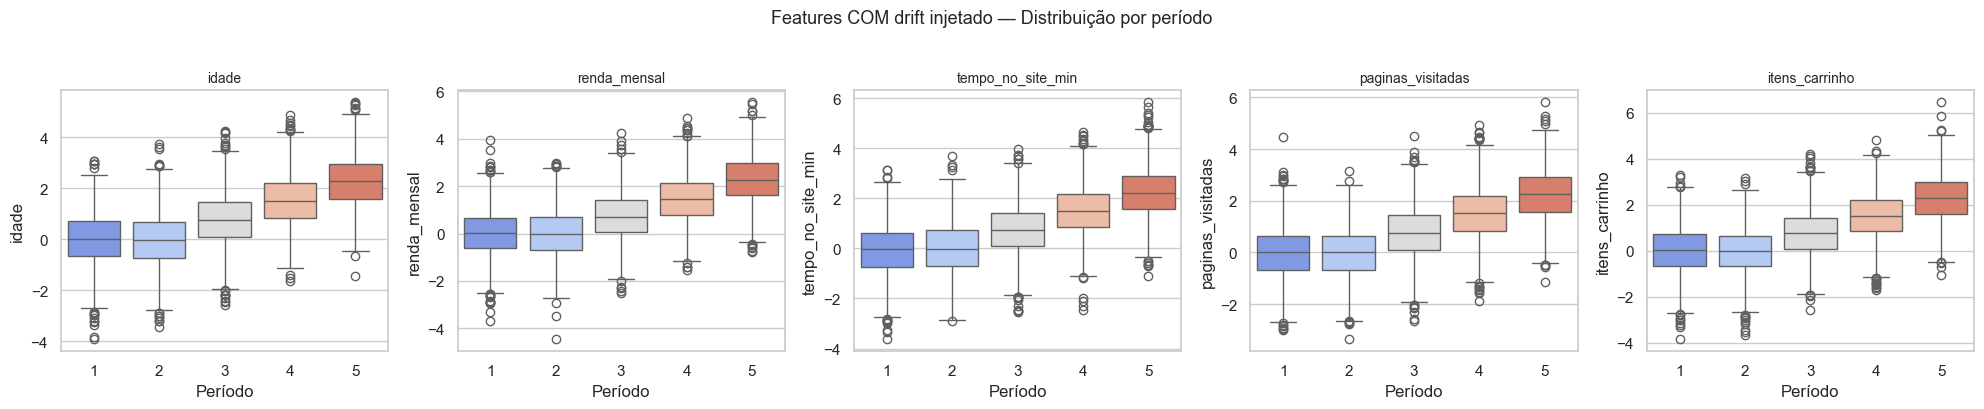

In [5]:
# Boxplots das 5 primeiras features (com drift injetado) por período
features_com_drift = DataPreprocessor.FEATURE_NAMES[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, features_com_drift):
    sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="coolwarm")
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("Período")

fig.suptitle("Features COM drift injetado — Distribuição por período", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_75728\3664143154.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="Greens")
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_75728\3664143154.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="Greens")
C:\Users\diogomiyake\AppData\Local\Temp\ipykernel_75728\3664143154.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="Greens")
C:\Users\diogomiyake\AppD

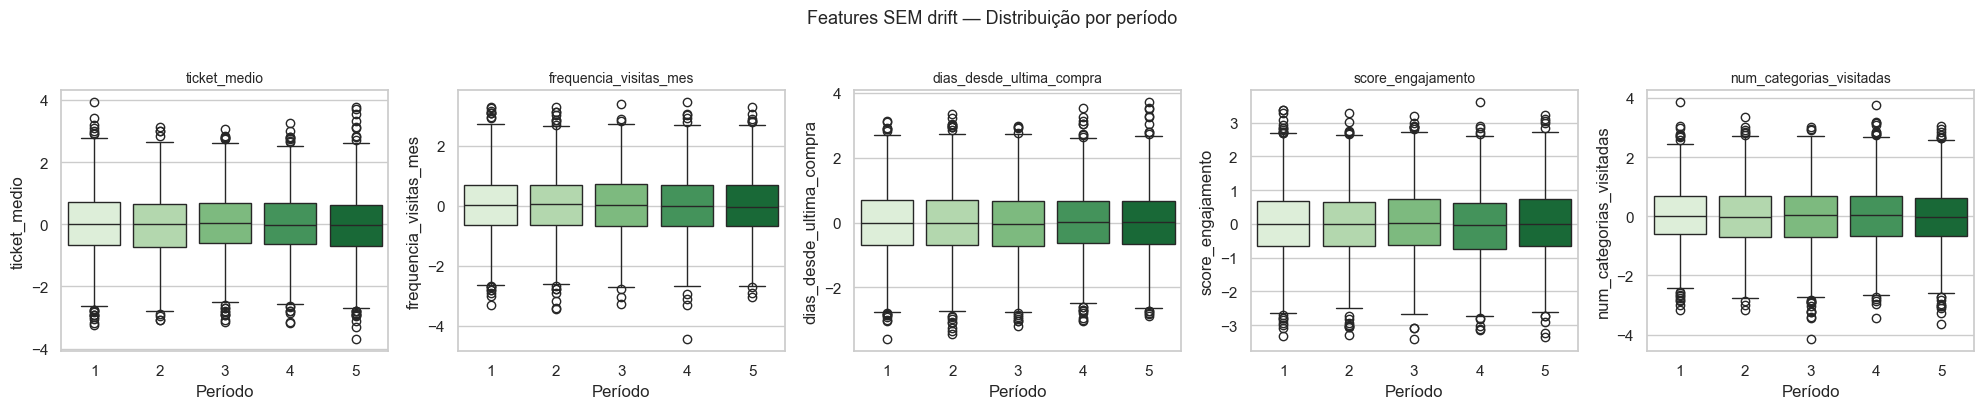

In [6]:
# Boxplots das 5 últimas features (sem drift) por período
features_sem_drift = DataPreprocessor.FEATURE_NAMES[5:]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, features_sem_drift):
    sns.boxplot(data=df, x="periodo", y=feat, ax=ax, palette="Greens")
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("Período")

fig.suptitle("Features SEM drift — Distribuição por período", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Histogramas comparativos: Referência vs. Drift

Implementa a visualização de histogramas comparativos conforme sugerido
no **Vídeo 3** (*Detectando Drift na Prática com Python*).

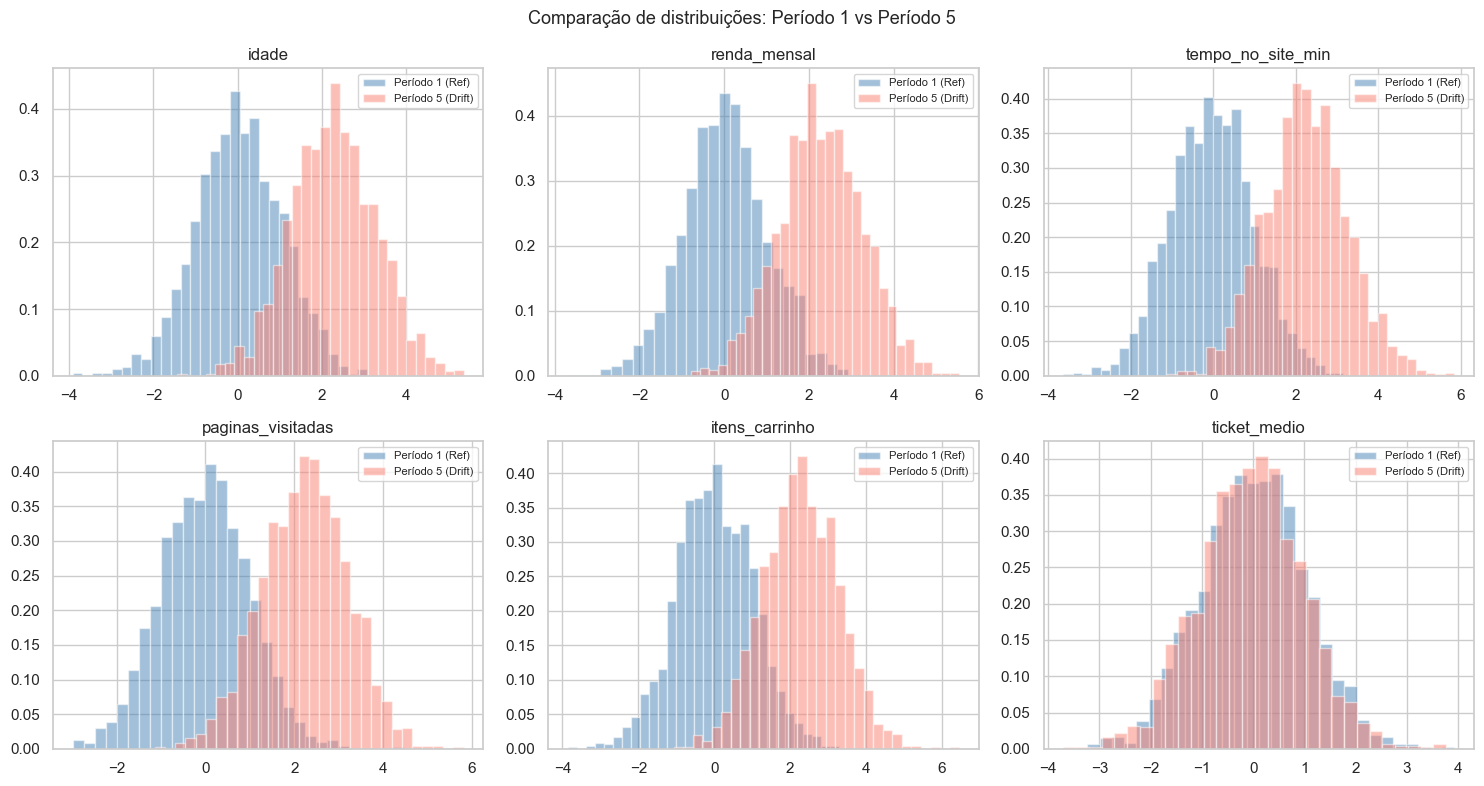

In [7]:
from src.evaluation import plot_distribution_comparison

# Compara período 1 (referência) vs período 5 (drift máximo)
df_ref = df[df["periodo"] == 1]
df_drift = df[df["periodo"] == 5]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (ax, feat) in enumerate(zip(axes.ravel(), features_com_drift + [features_sem_drift[0]])):
    ax.hist(df_ref[feat], bins=30, alpha=0.5, label="Período 1 (Ref)", color="steelblue", density=True)
    ax.hist(df_drift[feat], bins=30, alpha=0.5, label="Período 5 (Drift)", color="salmon", density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

fig.suptitle("Comparação de distribuições: Período 1 vs Período 5", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Estatísticas por Período

Monitoramos médias e desvios-padrão ao longo do tempo — conforme recomendado
na seção *Saiba Mais — Monitoramento e Detecção de Drift*.

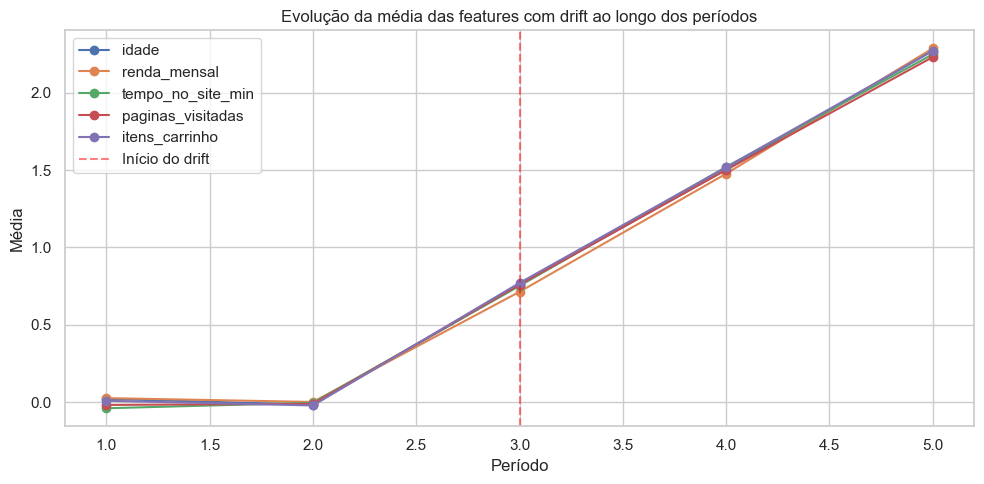

In [8]:
# Média por período para features com drift
stats = df.groupby("periodo")[features_com_drift].mean()

fig, ax = plt.subplots(figsize=(10, 5))
stats.plot(ax=ax, marker="o")
ax.set_xlabel("Período")
ax.set_ylabel("Média")
ax.set_title("Evolução da média das features com drift ao longo dos períodos")
ax.axvline(x=3, color="red", linestyle="--", alpha=0.5, label="Início do drift")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Correlação entre Features

Verificamos se a estrutura de correlação muda com o drift.

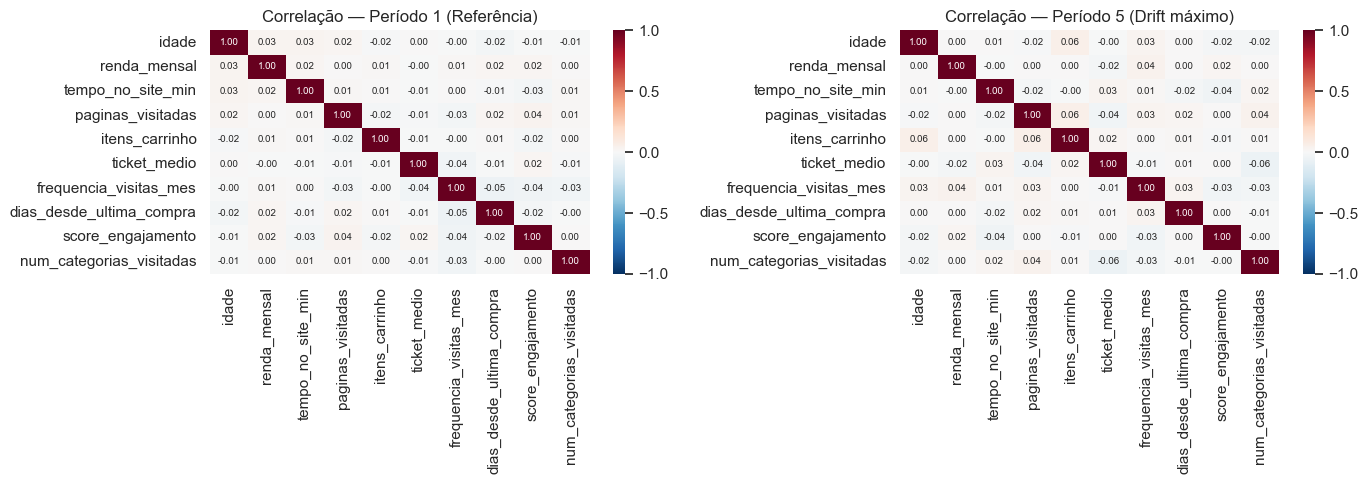

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlação no período 1 (sem drift)
corr1 = df[df["periodo"] == 1][DataPreprocessor.FEATURE_NAMES].corr()
sns.heatmap(corr1, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], vmin=-1, vmax=1, annot_kws={"size": 7})
axes[0].set_title("Correlação — Período 1 (Referência)")

# Correlação no período 5 (com drift)
corr5 = df[df["periodo"] == 5][DataPreprocessor.FEATURE_NAMES].corr()
sns.heatmap(corr5, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[1], vmin=-1, vmax=1, annot_kws={"size": 7})
axes[1].set_title("Correlação — Período 5 (Drift máximo)")

plt.tight_layout()
plt.show()

## 6. Distribuição do Target por Período

Conforme a definição do material, neste dataset simulamos **data drift puro
(covariate shift)** — $P(Y|X)$ não muda. Porém, como a distribuição de $X$
muda, a distribuição marginal de $Y$ pode se alterar levemente.

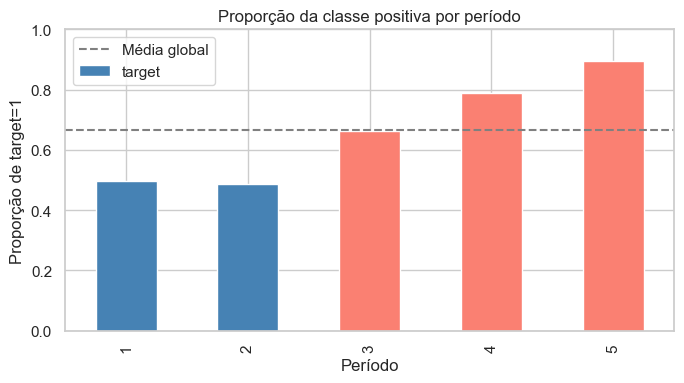

In [10]:
target_by_period = df.groupby("periodo")["target"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
target_by_period.plot(kind="bar", ax=ax, color=["steelblue", "steelblue", "salmon", "salmon", "salmon"])
ax.set_xlabel("Período")
ax.set_ylabel("Proporção de target=1")
ax.set_title("Proporção da classe positiva por período")
ax.set_ylim(0, 1)
ax.axhline(y=df["target"].mean(), color="gray", linestyle="--", label="Média global")
ax.legend()
plt.tight_layout()
plt.show()

## Resumo

Neste notebook, realizamos a **análise exploratória** do dataset sintético e
identificamos visualmente a presença de **data drift** nas features demográficas
(idade, renda, etc.) a partir do período 3.

**Principais observações:**
- As 5 primeiras features apresentam deslocamento claro na média a partir do período 3
- As 5 últimas features permanecem estáveis (sem drift)
- A estrutura de correlação entre features se mantém semelhante
- A proporção do target pode variar levemente devido ao covariate shift

**Próximo:** [02_treinamento.ipynb](02_treinamento.ipynb) — Treinamento do modelo
e detecção estatística de drift com teste Kolmogorov-Smirnov.